# Roadmap

1. Primero probar con una grid search con tamaño de ventana predefinido sin selección de características para encontrar un modelo base.

2. Probar distintos tamaños de ventanas, usando la configuración obtenida anteriormente mediante grid search.

3. Selección de características teniendo en cuenta el tamaño de ventana del paso anterior y la configuración de hiperparametros encontrada.

4. Evaluacion de modelos y ajuste de hiperparámetros.


# Funciones:

In [1]:
import os
import gc
import pandas as pd
import numpy as np
import neurokit2 as nk
import ast
import warnings

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold, cross_val_score, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, make_scorer
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 123

## Extracción de ventanas con solapamiento:

In [2]:

def extract_windows(path, sr=500, window_size = 30, overlap_sec = 10):

    SAMPLES_PER_WINDOW = sr * window_size
    OVERLAP_SAMPLES = sr * overlap_sec
    STEP_SIZE = SAMPLES_PER_WINDOW - OVERLAP_SAMPLES

    all_session_rows = []

    for subject in os.listdir(path):
        subject_path = os.path.join(path, subject)
        
        # skip non directories
        if not os.path.isdir(subject_path):
            continue
            
        for file in os.listdir(subject_path):
            file_path = os.path.join(subject_path, file)
            
            # Load the data
            df_physio = pd.read_csv(file_path)
            
            # Extract activity from filename 
            activity = os.path.basename(file_path).split('.')[0].split('_')[1]

            # Extract the signals
            raw_signals = df_physio[['ECG', 'EDA', 'RR']].values
            total_samples = len(raw_signals)
            
            # If the file is shorter than one window, skip it to avoid errors
            if total_samples < SAMPLES_PER_WINDOW:
                continue

            # how many overlapping windows we can fit
            num_windows = (total_samples - SAMPLES_PER_WINDOW) // STEP_SIZE + 1

            # Slide the window across the data
            for w in range(num_windows):
                start_idx = w * STEP_SIZE
                end_idx = start_idx + SAMPLES_PER_WINDOW
                
                # Slice the array
                window_data = raw_signals[start_idx:end_idx]

                all_session_rows.append({
                    'subject': subject,
                    'activity': activity,
                    'window_id': w,
                    'ECG': window_data[:, 0].tolist(), 
                    'EDA': window_data[:, 1].tolist(),
                    'RR':  window_data[:, 2].tolist()
                })

    return pd.DataFrame(all_session_rows)

## Extracción de características con Neurokit2 y preprocesamiento:

In [3]:
# extraction function for a single row
def extract_nk2_features(row, sr=500):
    ecg_raw = np.array(row['ECG'])
    eda_raw = np.array(row['EDA'])
    rsp_raw = np.array(row['RR'])
    
    features = {}
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        
        # ECG
        try:
            # clean and process the raw signal
            ecg_signals, _ = nk.ecg_process(ecg_raw, sampling_rate=sr)
            ecg_feat = nk.ecg_intervalrelated(ecg_signals) #features
            for col in ecg_feat.columns:
                features[col] = ecg_feat[col].iloc[0]
        except Exception:
            pass # If the window is too noisy, leave features empty (NaN)

        # EDA
        try:
            eda_signals, _ = nk.eda_process(eda_raw, sampling_rate=sr)
            eda_feat = nk.eda_intervalrelated(eda_signals)
            for col in eda_feat.columns:
                features[col] = eda_feat[col].iloc[0]
        except Exception:
            pass

        # RR
        try:
            rsp_signals, _ = nk.rsp_process(rsp_raw, sampling_rate=sr)
            rsp_feat = nk.rsp_intervalrelated(rsp_signals)
            for col in rsp_feat.columns:
                features[col] = rsp_feat[col].iloc[0]
        except Exception:
            pass
        
    # Return as pd.Series
    return pd.Series(features)


#The [[v]] values are obviously wrong, so we need to extract them
def extract_scalar(val):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return np.nan

    try:
        return float(val[0][0])
    except (TypeError, IndexError, ValueError):
        return np.nan
    


def preprocess(df, threshold=30):
    '''
    Preprocesamiento centrado en la limpieza del dataframe de features.
    1. Elimina infs.
    2. Elimina columnas con NaNs superiores al porcentaje igual a "threshold"
    3. Elimina filas con algún NaN.
    4. Extrae los valores con formato [[v]].
    '''
    df = df.replace([np.inf, -np.inf], np.nan)

    missing_percentages = df.isna().sum() / len(df) * 100

    cols_to_drop = missing_percentages[missing_percentages > threshold].index
    df = df.drop(columns=cols_to_drop)
    df = df.dropna()

    
    feature_cols = [col for col in df.select_dtypes(include="object").columns if col not in ['subject', 'activity', 'window_id']]
    for col in feature_cols:
        df[col] = df[col].apply(extract_scalar)
    
    return df

def normalize(df, by=['Baseline', 'Relax'], clean = True):
    '''
    Normalización por sujeto usando Z-score, en base a la actividad especificada con param "by".
    '''

    feature_cols = [col for col in df.columns if col not in ['subject', 'activity', 'window_id']]

    # Aislar los datos de baseline para calcular la referencia
    #df_baseline = df[df['activity'] == 'Baseline']
    df_baseline = df[df['activity'].isin(by)]


    # Calcular la media y std de cada característica durante el baseline, agrupado por sujeto
    baseline_means = df_baseline.groupby('subject')[feature_cols].mean().reset_index()
    baseline_stds = df_baseline.groupby('subject')[feature_cols].std().reset_index()

    # Fusionar (merge) estas medias con el dataframe original
    # con sufijos a las columnas para diferenciarlas
    df_norm = pd.merge(df, baseline_means, on='subject', suffixes=('', '_mean'))
    df_norm = pd.merge(df_norm, baseline_stds, on='subject', suffixes=('', '_std'))

    # Aplicar la normalización z score
    # Restamos el valor base al valor de la ventana actual para aislar el cambio
    for col in feature_cols:
        df_norm[col] = (df_norm[col] - df_norm[f"{col}_mean"]) / (df_norm[f"{col}_std"] + 1e-8)

    # Eliminar las columnas _mean, _std
    columnas_auxiliares = [f"{col}_mean" for col in feature_cols] + [f"{col}_std" for col in feature_cols]
    df_norm.drop(columns=columnas_auxiliares, inplace=True)

    if clean:
        df_norm = preprocess(df_norm)

    return df_norm


def feature_extraction_and_normalization(df, threshold=30, norm_by=['Baseline', 'Relax'], clean = True):
    '''
    Aplicar el proceso global de extracción de características + limpieza + normalización + limpieza
    '''
    features_df = df.apply(extract_nk2_features, axis=1) #apply feature extraction per row
    df_features = pd.concat(
    [df[['subject', 'activity', 'window_id']], features_df], 
    axis=1
    )

    df_features = preprocess(df_features, threshold=threshold)
    df_features = normalize(df_features, by = norm_by, clean = clean)

    return df_features

## Split de datos por sujeto y evaluación de modelos:

In [9]:
from sklearn.model_selection import GroupShuffleSplit

def get_group_idx_updated(df, test_size=0.20, random_state=RANDOM_STATE, exclude_acts=['Baseline', 'Relax']):
    # 1. Excluir las actividades usadas para normalizar
    df_model = df[~df['activity'].isin(exclude_acts)].copy()

    # Aseguramos que la etiqueta sea un entero (0 No estrés, 1 Estrés)
    df_model['target'] = df_model['target'].astype(int)

    # Separamos las características (X) de las etiquetas y metadatos
    # Mantenemos las columnas dinámicas para que funcione con cualquier tamaño de ventana
    cols_to_exclude = ['subject', 'activity', 'window_id', 'target', 'subject/task', 'subject_activity']
    feature_cols = [col for col in df_model.columns if col not in cols_to_exclude]

    X = df_model[feature_cols]
    y = df_model['target']
    subjects = df_model['subject']
    tasks = df_model['subject/task'] # Necesario para la agregación a nivel de tarea luego

    # Configuramos la división: agrupado por sujetos para evitar data leakage
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)

    # Obtenemos los índices de las filas (estos son índices posicionales 0, 1, 2...)
    train_pos_idx, test_pos_idx = next(gss.split(X, y, groups=subjects))

    return train_pos_idx, test_pos_idx, X, y, subjects, tasks


def train_test_split_per_subject_updated(df, test_size=0.20, random_state=RANDOM_STATE, exclude_acts=['Baseline', 'Relax']):
    # Llamamos a la función interna
    train_idx, test_idx, X, y, subjects, tasks = get_group_idx_updated(
        df, test_size=test_size, random_state=random_state, exclude_acts=exclude_acts
    )

    # Creamos los DataFrames finales de entrenamiento y prueba
    X_train = X.iloc[train_idx].copy()
    y_train = y.iloc[train_idx].copy()

    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()
    
    # Extraemos también los metadatos correspondientes a train y test
    tasks_train = tasks.iloc[train_idx].copy()
    tasks_test = tasks.iloc[test_idx].copy()
    train_subjects = subjects.iloc[train_idx]
    test_subjects = subjects.iloc[test_idx]

    print(f"Sujetos en Train: {train_subjects.nunique()}")
    print(f"Sujetos en Test: {test_subjects.nunique()}")
    print(f"Ventanas en Train: {len(X_train)} | Ventanas en Test: {len(X_test)}")

    # Retornamos todo lo necesario para la GridSearch y la evaluación posterior
    return X_train, X_test, y_train, y_test, subjects, train_idx, test_idx, tasks_train, tasks_test


def evaluate_and_plot(y_test, y_pred, y_pred_proba, stress_act = 'Counting2', non_stress_act = 'Breathing'):

    print(classification_report(y_test, y_pred, target_names=[f'{non_stress_act}(0)', f'{stress_act}(1)']))
    print('Average precision score:', np.round(average_precision_score(y_test, y_pred_proba), 4))
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicción No Estrés', 'Predicción Estrés'],
                yticklabels=['Realidad No Estrés', 'Realidad Estrés'])
    plt.title('Matriz de Confusión')
    plt.show()

## Feature selection:

In [10]:

#Eliminar columnas con alta correlación, calculada sobre los datos de train.
def drop_correlated_features(X_train, X_test, threshold=0.95):
    
    # Calculate correlation matrix on TRAIN data
    corr_matrix = X_train.corr().abs()

    # elect the upper triangle to avoid dropping both features in a pair
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find features to drop based on the threshold
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    
    # Drop
    X_train_filtered = X_train.drop(columns=to_drop)
    X_test_filtered = X_test.drop(columns=to_drop)
    
    return X_train_filtered, X_test_filtered

#APlicar RFE
def apply_rfe(model, X_train, X_test, y_train, num_features=20):
    
    # base estimator
    #rf_estimator = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    
    # Set up RFE
    # step=1 means it drops the single worst feature one at a time
    rfe = RFE(estimator=model, n_features_to_select=num_features, step=1)
    
    # Fit RFE on the training data
    rfe.fit(X_train, y_train)
    
    # Extract the names of the features that survived
    selected_features = X_train.columns[rfe.support_].tolist()
        
    # Apply the selection mask to both Train and Test sets
    X_train_rfe = X_train[selected_features]
    X_test_rfe = X_test[selected_features]
    
    return X_train_rfe, X_test_rfe, selected_features


def gridSearch(base_model, param_grid, scoring, X_train, y_train, subjects, train_idx):
    # Grouped Cross Validation for the Grid Search
    gkf = GroupKFold(n_splits=5)

    # Initialize the Grid Search
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=gkf,
        scoring=scoring, #recall is firstly used as the previous models performed poorly with stressed windows.... BALANCED_ACC OR F1
        n_jobs=-1,
        verbose=2 # Prints progress
    )

    # We need to isolate the subject groups for the training data specifically
    train_subjects = subjects.iloc[train_idx] #subjects in train data

    # Fit the Grid Search using only the subjects in train data
    grid_search.fit(X_train, y_train, groups=train_subjects)

    print(f"Best score: {grid_search.best_score_:.4f}")
    print("Best Hyperparameters:")
    for param, value in grid_search.best_params_.items():
        print(f"- {param}: {value}")

    return grid_search

## 1. Búsqueda de un modelo base mediante GridSearch con tamaño de ventana fijo, sin selección de características.

- Tamaño de ventana = 30 s
- Solapamiento = 10 s

In [8]:
PATH = './data/original'
SR = 500
features_df = extract_features_on_the_fly(PATH, sr=SR, window_size=50, overlap_sec=0)
features_df = preprocess_updated(features_df, threshold=30)
features_df = normalize_updated(features_df, by=['Baseline', 'Relax'], clean=True)
features_df.to_csv('physiological_features_50s0overlap_normalized.csv', index=False)

In [6]:
features = ['subject','activity','window_id','ECG_Rate_Mean','HRV_MedianNN','HRV_Prc20NN','HRV_Prc80NN','HRV_MaxNN','HRV_PSS','HRV_C1d','HRV_SampEn','HRV_MSEn','SCR_Peaks_Amplitude_Mean','RSP_Rate_Mean','RAV_SD', 'RAV_RMSSD','RSP_RVT','RSP_Symmetry_RiseDecay']

In [7]:
features_df[features]

,subject,activity,window_id,ECG_Rate_Mean,HRV_MedianNN,HRV_Prc20NN,HRV_Prc80NN,HRV_MaxNN,HRV_PSS,HRV_C1d,HRV_SampEn,HRV_MSEn,SCR_Peaks_Amplitude_Mean,RSP_Rate_Mean,RAV_SD,RAV_RMSSD,RSP_RVT,RSP_Symmetry_RiseDecay
0,9j3o,Math,0,2.256235,-1.805680,-2.646599,-1.784998,-0.984719,-1.340743,0.725518,-2.324906,1.232014,0.611013,0.830990,1.007589,1.381084,-1.210533,-1.953227
1,9j3o,Baseline,0,1.121103,-1.021819,-1.177369,-0.844288,-1.373059,-0.498369,1.156821,-0.557656,0.629500,1.254005,1.497278,1.340272,1.368577,0.155412,-1.436866
2,9j3o,Reading,0,0.135155,0.284616,-0.883523,0.359822,0.568641,0.010003,2.906725,-1.856563,1.894711,0.484645,0.953938,0.290696,0.652360,-9.603128,-2.989048
3,9j3o,Stroop,0,0.879299,-0.704542,-0.851756,-1.117094,-2.649033,1.057722,-0.945827,-0.258376,0.946221,0.131715,1.960008,-0.295754,0.110222,2.499386,-2.579450
4,9j3o,Counting3,0,1.689312,-1.507066,-1.558575,-1.766184,-1.594968,-0.102969,-1.209756,-1.034081,0.821900,0.608828,0.320263,1.194095,1.912607,-5.671442,-2.671410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,b2l8,Baseline,0,1.489406,-1.466179,-1.482397,-1.422142,-1.473793,-0.437077,0.630319,0.338314,0.327772,1.496855,1.491197,0.240259,0.766330,-1.475840,-1.465837
1103,b2l8,Counting2,0,0.970673,-0.684217,-1.140112,-0.659145,-1.228161,-0.810495,-0.159694,-0.911615,0.830591,-0.016800,-0.523053,5.341310,7.640996,-0.999536,0.196775
1104,b2l8,Reading,0,2.016275,-1.954906,-1.935422,-1.964718,-0.245632,0.459126,0.355835,2.653754,0.630520,0.088951,-0.875776,0.337079,0.127004,-1.494688,-0.995419
1105,b2l8,Speaking,0,1.071453,-0.879708,-0.928700,-0.786311,-1.432855,1.983226,-8.095705,0.414360,1.719925,-0.050950,0.339359,4.742119,7.258809,-1.372036,-1.380392


In [8]:
features_df = pd.read_csv('physiological_features_50s0overlap_normalized.csv')
features_df[features].to_csv('physiological_features_50s0overlap_normalized.csv', index=False)

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

PATH = './data/original/'
gt = pd.read_csv('../labels_v2.csv', sep=';')

# 1. Extract windows (assuming default 30s)
df_raw_windows = extract_windows(PATH, window_size=30, overlap_sec=10)

# 2. Extract features and normalize (your pipeline)
df_features = feature_extraction_and_normalization(df_raw_windows)

# 3. Merge Ground Truth (Task-level labels)
df_features['subject/task'] = df_features['subject'].astype(str) + '_' + df_features['activity'].astype(str)
df = df_features.merge(gt[['subject/task', 'binary-stress']], on='subject/task', how='inner')
df = df.rename(columns={'binary-stress': 'target'})

# 4. Split Data (Using the generalized version that doesn't filter by activity)
X_train, X_test, y_train, y_test, subjects, train_idx, test_idx, tasks_train, tasks_test = train_test_split_per_subject_updated(df)

# 5. Grid Search
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
param_grid = {
    'n_estimators': [10, 20, 50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Run your custom gridSearch function
best_rf_model = gridSearch(
    base_model=base_rf, 
    param_grid=param_grid, 
    scoring='balanced_accuracy', 
    X_train=X_train, 
    y_train=y_train, 
    subjects=subjects, 
    train_idx=train_idx
)

best_params = best_rf_model.best_params_

Sujetos en Train: 49
Sujetos en Test: 13
Ventanas en Train: 1062 | Ventanas en Test: 314
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END max_depth=None, min_

Best score: 0.6255

Best Hyperparameters:
- max_depth: 10
- min_samples_split: 5
- n_estimators: 200

## 2. Búsqueda del tamaño de ventana, haciendo uso del modelo base anterior.

In [ ]:
import os
import pandas as pd

def get_durations(path, sr=500):
    records = []
    
    for subject in os.listdir(path):
        subject_path = os.path.join(path, subject)
        
        if not os.path.isdir(subject_path):
            continue
            
        for file in os.listdir(subject_path):
                
            file_path = os.path.join(subject_path, file)
            
            activity = os.path.basename(file_path).split('.')[0].split('_')[1]
            
            # Leemos solo la primera columna
            try:
                df_dummy = pd.read_csv(file_path, usecols=[0])
                total_samples = len(df_dummy)
                duration_sec = total_samples / sr
                
                records.append({
                    'Sujeto': subject,
                    'Actividad': activity,
                    'Duracion_Segundos': duration_sec
                })
            except Exception as e:
                print(f"Error leyendo {file}: {e}")

    # Convertimos a DataFrame
    df_durations = pd.DataFrame(records)
    
    
    return df_durations

PATH = '../../StressIDDataset/StressID/StressID Dataset/Physiological'
duraciones = get_durations(PATH, sr=500)

print('Duración mínima Breathing: ', duraciones['Breathing'].min(), 's')
print('Duración mínima Counting2: ', duraciones['Counting2'].min(), 's')

Duración mínima Breathing:  180.0 s
Duración mínima Counting2:  60.0 s


Todos los individuos presentan las actividades seleccionadas, y tienen duración mínima de 60 segundos, luego probar hasta una longitud de 60 segundos parece lo natural.

Ahora, para la fase de pruebas, se debe tener en cuenta que los individuos de train deben ser los mismos para todas las combinaciones a probar. Para ello, la idea sería extraer o separar de antemano los individuos. Para este caso, las funciones anteriormente definidas no nos sirven, ya que al estar cambiando el tamaño de ventana y generando features nuevamente, los índices devueltos no se mantienen intactos... Luego necesitamos nuevas funciones que se adapten a este caso:

In [13]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

def get_test_subjects_updated(df, test_size=0.20, random_state=42, exclude_acts=['Baseline', 'Relax']):
    """
    Extrae la lista de sujetos que irán a test, excluyendo baselines.
    """
    df_model = df[~df['activity'].isin(exclude_acts)].copy()
    
    # Solo necesitamos los sujetos para hacer la división
    subjects = df_model['subject']
    
    # Arrays dummy para que gss funcione
    X_dummy = np.zeros(len(subjects))
    y_dummy = np.zeros(len(subjects))

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X_dummy, y_dummy, groups=subjects))

    # Obtenemos los sujetos de test
    test_subjects_list = subjects.iloc[test_idx].unique().tolist()
    
    print(f"Sujetos seleccionados para Test: {test_subjects_list}")
    return test_subjects_list


def split_data_by_subjects_updated(df, test_subjects_list, exclude_acts=['Baseline', 'Relax']):
    """
    Separa el dataframe usando LA LISTA ESTÁTICA de sujetos de test predefinida.
    """
    df_model = df[~df['activity'].isin(exclude_acts)].copy()
    df_model['target'] = df_model['target'].astype(int)

    # Identificamos las columnas de características dinámicamente
    cols_to_exclude = ['subject', 'activity', 'window_id', 'target', 'subject/task', 'subject_activity']
    feature_cols = [col for col in df_model.columns if col not in cols_to_exclude]

    # Split basado estrictamente en la lista de sujetos
    train_df = df_model[~df_model['subject'].isin(test_subjects_list)]
    test_df = df_model[df_model['subject'].isin(test_subjects_list)]

    # --- TRAIN ---
    X_train = train_df[feature_cols]
    y_train = train_df['target']
    groups_train = train_df['subject'] # Importante para GroupKFold en GridSearch
    tasks_train = train_df['subject/task']

    # --- TEST ---
    X_test = test_df[feature_cols]
    y_test = test_df['target']
    tasks_test = test_df['subject/task']

    return X_train, X_test, y_train, y_test, groups_train, tasks_train, tasks_test

In [15]:
best_hyperparams = {'max_depth':10, 'min_samples_split': 5, 'n_estimators': 200}

In [4]:
import os
import numpy as np
import pandas as pd
import neurokit2 as nk
import warnings
import gc

import os
import numpy as np
import pandas as pd
import neurokit2 as nk
import warnings
import gc

def get_safe_scalar(val):
    """Extrae el float limpio, evitando el problema de los [[v]] de NeuroKit2"""
    try:
        if isinstance(val, (list, np.ndarray, pd.Series)):
            return float(np.ravel(val)[0])
        return float(val)
    except:
        return np.nan

def extract_features_on_the_fly(path, sr=500, window_size=30, overlap_sec=10):
    SAMPLES_PER_WINDOW = sr * window_size
    OVERLAP_SAMPLES = sr * overlap_sec
    STEP_SIZE = SAMPLES_PER_WINDOW - OVERLAP_SAMPLES

    all_features = []

    for subject in os.listdir(path):
        subject_path = os.path.join(path, subject)
        if not os.path.isdir(subject_path):
            continue
            
        for file in os.listdir(subject_path):
            # Solo procesamos los archivos .txt
            if not file.endswith('.txt'): 
                continue
                
            file_path = os.path.join(subject_path, file)
            activity = os.path.basename(file_path).split('.')[0].split('_')[1]

            # Pandas leerá el .txt perfectamente si por dentro es como un CSV
            df_physio = pd.read_csv(file_path) 
            
            if not all(col in df_physio.columns for col in ['ECG', 'EDA', 'RR']):
                del df_physio
                continue

            raw_signals = df_physio[['ECG', 'EDA', 'RR']].values
            total_samples = len(raw_signals)
            
            del df_physio
            
            if total_samples < SAMPLES_PER_WINDOW:
                continue

            num_windows = (total_samples - SAMPLES_PER_WINDOW) // STEP_SIZE + 1

            for w in range(num_windows):
                start_idx = w * STEP_SIZE
                end_idx = start_idx + SAMPLES_PER_WINDOW
                
                window_data = raw_signals[start_idx:end_idx]
                ecg_raw = window_data[:, 0]
                eda_raw = window_data[:, 1]
                rsp_raw = window_data[:, 2]

                feat_dict = {
                    'subject': subject,
                    'activity': activity,
                    'window_id': w
                }

                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    
                    try:
                        ecg_signals, _ = nk.ecg_process(ecg_raw, sampling_rate=sr)
                        ecg_feat = nk.ecg_intervalrelated(ecg_signals)
                        for col in ecg_feat.columns:
                            feat_dict[col] = get_safe_scalar(ecg_feat[col].iloc[0])
                    except Exception:
                        pass 

                    try:
                        eda_signals, _ = nk.eda_process(eda_raw, sampling_rate=sr)
                        eda_feat = nk.eda_intervalrelated(eda_signals)
                        for col in eda_feat.columns:
                            feat_dict[col] = get_safe_scalar(eda_feat[col].iloc[0])
                    except Exception:
                        pass

                    try:
                        rsp_signals, _ = nk.rsp_process(rsp_raw, sampling_rate=sr)
                        rsp_feat = nk.rsp_intervalrelated(rsp_signals)
                        for col in rsp_feat.columns:
                            feat_dict[col] = get_safe_scalar(rsp_feat[col].iloc[0])
                    except Exception:
                        pass

                all_features.append(feat_dict)
            
            del raw_signals
            gc.collect()

    return pd.DataFrame(all_features)

def preprocess_updated(df, threshold=30):
    '''
    Preprocesamiento limpio y rápido.
    1. Elimina infs.
    2. Elimina columnas con NaNs superiores al umbral.
    3. Elimina filas con algún NaN.
    '''
    df = df.replace([np.inf, -np.inf], np.nan)

    missing_percentages = df.isna().sum() / len(df) * 100
    cols_to_drop = missing_percentages[missing_percentages > threshold].index
    
    df = df.drop(columns=cols_to_drop)
    df = df.dropna().reset_index(drop=True)
    
    return df

# Tu función normalize sigue EXACTAMENTE igual, solo asegúrate de que llame a preprocess_updated al final
def normalize_updated(df, by=['Baseline', 'Relax'], clean=True):
    feature_cols = [col for col in df.columns if col not in ['subject', 'activity', 'window_id']]
    df_baseline = df[df['activity'].isin(by)]

    baseline_means = df_baseline.groupby('subject')[feature_cols].mean().reset_index()
    baseline_stds = df_baseline.groupby('subject')[feature_cols].std().reset_index()

    df_norm = pd.merge(df, baseline_means, on='subject', suffixes=('', '_mean'))
    df_norm = pd.merge(df_norm, baseline_stds, on='subject', suffixes=('', '_std'))

    for col in feature_cols:
        df_norm[col] = (df_norm[col] - df_norm[f"{col}_mean"]) / (df_norm[f"{col}_std"] + 1e-8)

    columnas_auxiliares = [f"{col}_mean" for col in feature_cols] + [f"{col}_std" for col in feature_cols]
    df_norm.drop(columns=columnas_auxiliares, inplace=True)

    if clean:
        df_norm = preprocess_updated(df_norm)

    return df_norm

In [ ]:
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

PATH = './data/original'
SR = 500
WINDOW_SIZE = np.arange(20, 61, 10)
RANDOM_STATE = 123

# Asumimos que gt (ground truth labels) ya está cargado en memoria como un DataFrame
# gt = pd.read_csv('ruta/al/csv/de/etiquetas.csv')

scores = []

# 1. Congelar los sujetos de Test ANTES del bucle
# NOTA: 'base_features_df' debe ser un dataset (ej. ventana 30s) que YA haya hecho merge
# con el 'gt' y tenga la columna 'target' para que la función la reconozca.
test_subjects = get_test_subjects_updated(df, test_size=0.20, random_state=RANDOM_STATE)
del df
gc.collect()

cv = GroupKFold(n_splits=5) 
scoring_metrics = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

base_model = RandomForestClassifier(**best_params, class_weight='balanced', random_state=RANDOM_STATE)


for window_size in WINDOW_SIZE:
    OVERLAP_SEC = np.arange(0, ((window_size * 3) // 4) + 1, 5)

    for overlap_sec in OVERLAP_SEC:
        print(f'\nEvaluating... Window size: {window_size}s; Overlap: {overlap_sec}s')
        
        # 1. Extracción on-the-fly (Súper eficiente en RAM)
        features_df = extract_features_on_the_fly(PATH, sr=SR, window_size=window_size, overlap_sec=overlap_sec)
        
        # 2. Normalizar y Limpiar
        # Como features_df ya son características numéricas, saltamos directo a preprocesar y normalizar
        features_df = preprocess_updated(features_df, threshold=30)
        features_df = normalize_updated(features_df, by=['Baseline', 'Relax'], clean=True)

        # 3. Propagación de Etiquetas (Merge)
        features_df['subject/task'] = features_df['subject'].astype(str) + '_' + features_df['activity'].astype(str)
        df_ws = features_df.merge(gt[['subject/task', 'binary-stress']], on='subject/task', how='inner')
        df_ws = df_ws.rename(columns={'binary-stress': 'target'})
        
        del features_df
        gc.collect()

        # 4. Split seguro
        X_train, X_test, y_train, y_test, groups_train, tasks_train, tasks_test = split_data_by_subjects_updated(
            df_ws, 
            test_subjects, 
            exclude_acts=['Baseline', 'Relax']
        )
        del df_ws
        gc.collect()

        # [Recomendación Opcional]: Mantener n_jobs a la mitad de tus cores (ej. si tienes 8, usa 4)
        cv_results = cross_validate(
            base_model,
            X_train,
            y_train, 
            groups=groups_train, 
            cv=cv, 
            scoring=scoring_metrics, 
            n_jobs=-1 # Deberías poder usar -1 ahora que la huella de memoria es tan pequeña
        )

        # 5. Guardar resultados
        scores.append({
            'window_size': window_size,
            'overlap_sec': overlap_sec,
            'accuracy': np.mean(cv_results['test_accuracy']),
            'balanced_accuracy': np.mean(cv_results['test_balanced_accuracy']),
            'precision': np.mean(cv_results['test_precision']),
            'recall': np.mean(cv_results['test_recall']),
            'f1': np.mean(cv_results['test_f1'])
        })

        del X_train, X_test, y_train, y_test, groups_train, tasks_train, tasks_test, cv_results
        gc.collect()

In [20]:
# Final: Visualizar las mejores combinaciones
scores_df = pd.DataFrame(scores).sort_values(by='balanced_accuracy', ascending=False).reset_index(drop=True)
print("\n=== Top 5 Mejores Configuraciones Temporales ===")
print(scores_df.head(5).to_string(index=False))


=== Top 5 Mejores Configuraciones Temporales ===
 window_size  overlap_sec  accuracy  balanced_accuracy  precision   recall       f1
          50            0  0.672674           0.677766   0.652204 0.659930 0.649823
          60           30  0.679341           0.674692   0.633737 0.595968 0.603178
          60           15  0.657369           0.671186   0.631707 0.645915 0.619712
          60           25  0.666592           0.666424   0.620932 0.599905 0.596361
          50           20  0.674284           0.663408   0.630862 0.588618 0.606735


In [21]:
scores_df.to_csv('./window_size_results.csv', index=False)

In [ ]:
scores_df = pd.read_csv('./window_size_results.csv')

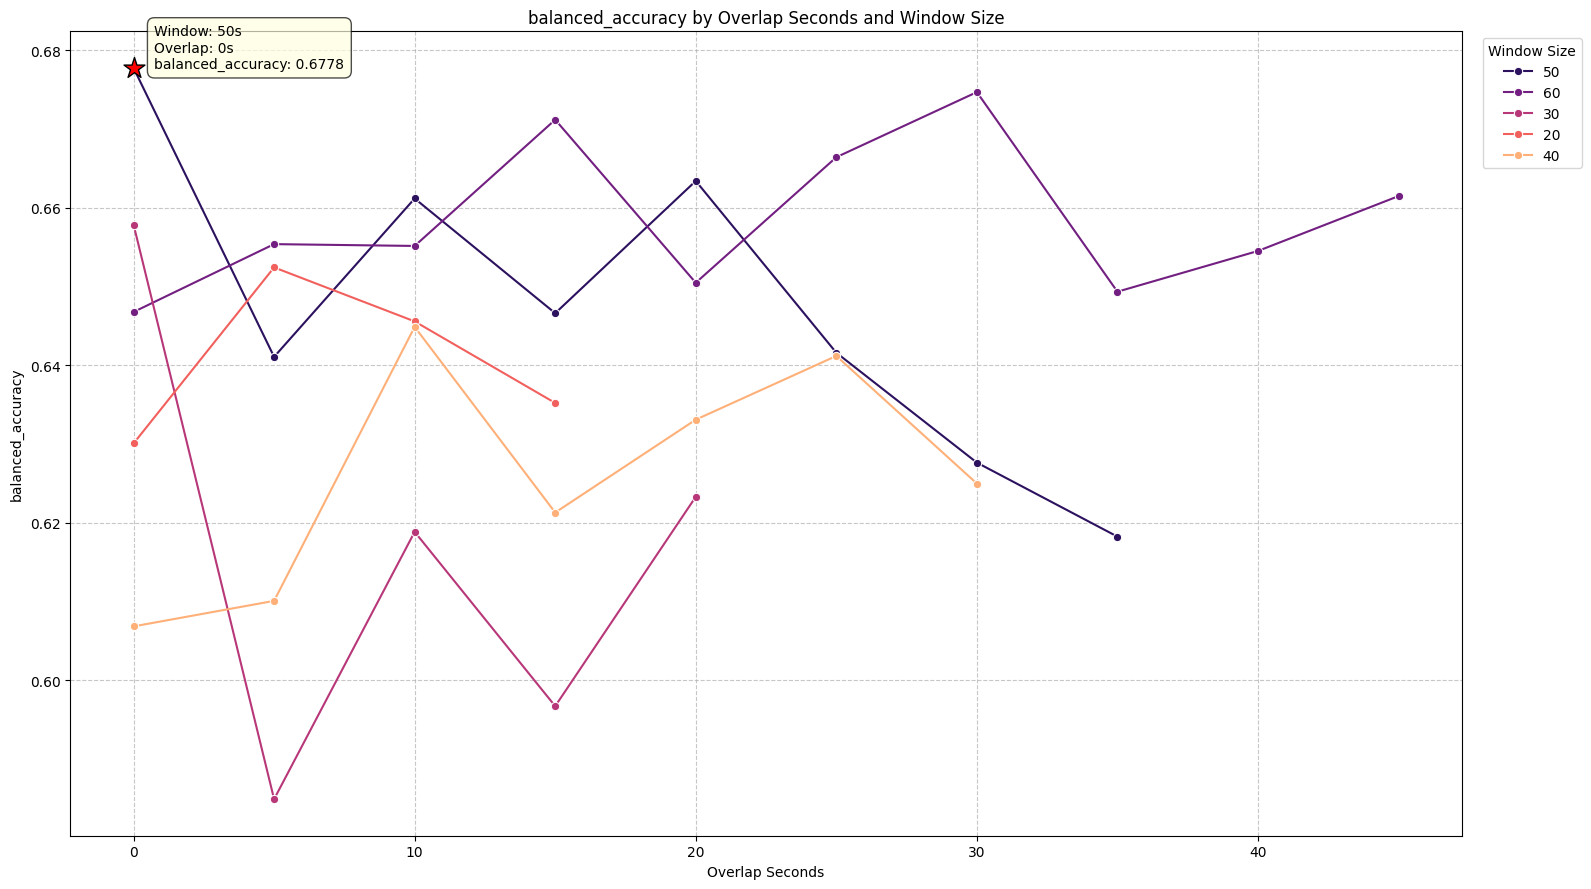

In [10]:
def plot_stress_metric(df, metric_col):
    plt.figure(figsize=(16, 9))
    df['window_size'] = df['window_size'].astype(str)
    
    # Create the lineplot
    # hue='window_size' automatically creates separate lines for each window size
    # marker='o' adds dots to easily see where the actual data points are
    sns.lineplot(
        data=df, 
        x='overlap_sec',
        y=metric_col, 
        hue='window_size', 
        palette='magma',
        marker='o'
    )

    max_idx = df[metric_col].idxmax()
    best_row = df.loc[max_idx]
    
    best_score = best_row[metric_col]
    best_overlap = best_row['overlap_sec']
    best_window = best_row['window_size']
    #highlight the best score combination
    plt.scatter(
        x=best_overlap, 
        y=best_score, 
        color='red', 
        s=250,
        marker='*',
        edgecolor='black', 
        zorder=2
    )
    annotation_text = f"Window: {best_window}s\nOverlap: {best_overlap}s\n{metric_col}: {np.round(best_score, 4)}"
    plt.annotate(
        annotation_text,
        xy=(best_overlap, best_score),
        xytext=(15, 0), # Offset the text
        textcoords='offset points',
        bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", ec="black", alpha=0.7), # Yellow text box
        fontsize=10,
        color='black',
        zorder=5
    )
    
    # Formatting the plot
    plt.title(f'{metric_col} by Overlap Seconds and Window Size')
    plt.xlabel('Overlap Seconds',)
    plt.ylabel(metric_col)
    
    # Improve legend formatting
    plt.legend(title='Window Size',bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout() # Ensures the legend doesn't get cut off
    
    plt.show()

plot_stress_metric(scores_df, 'balanced_accuracy')

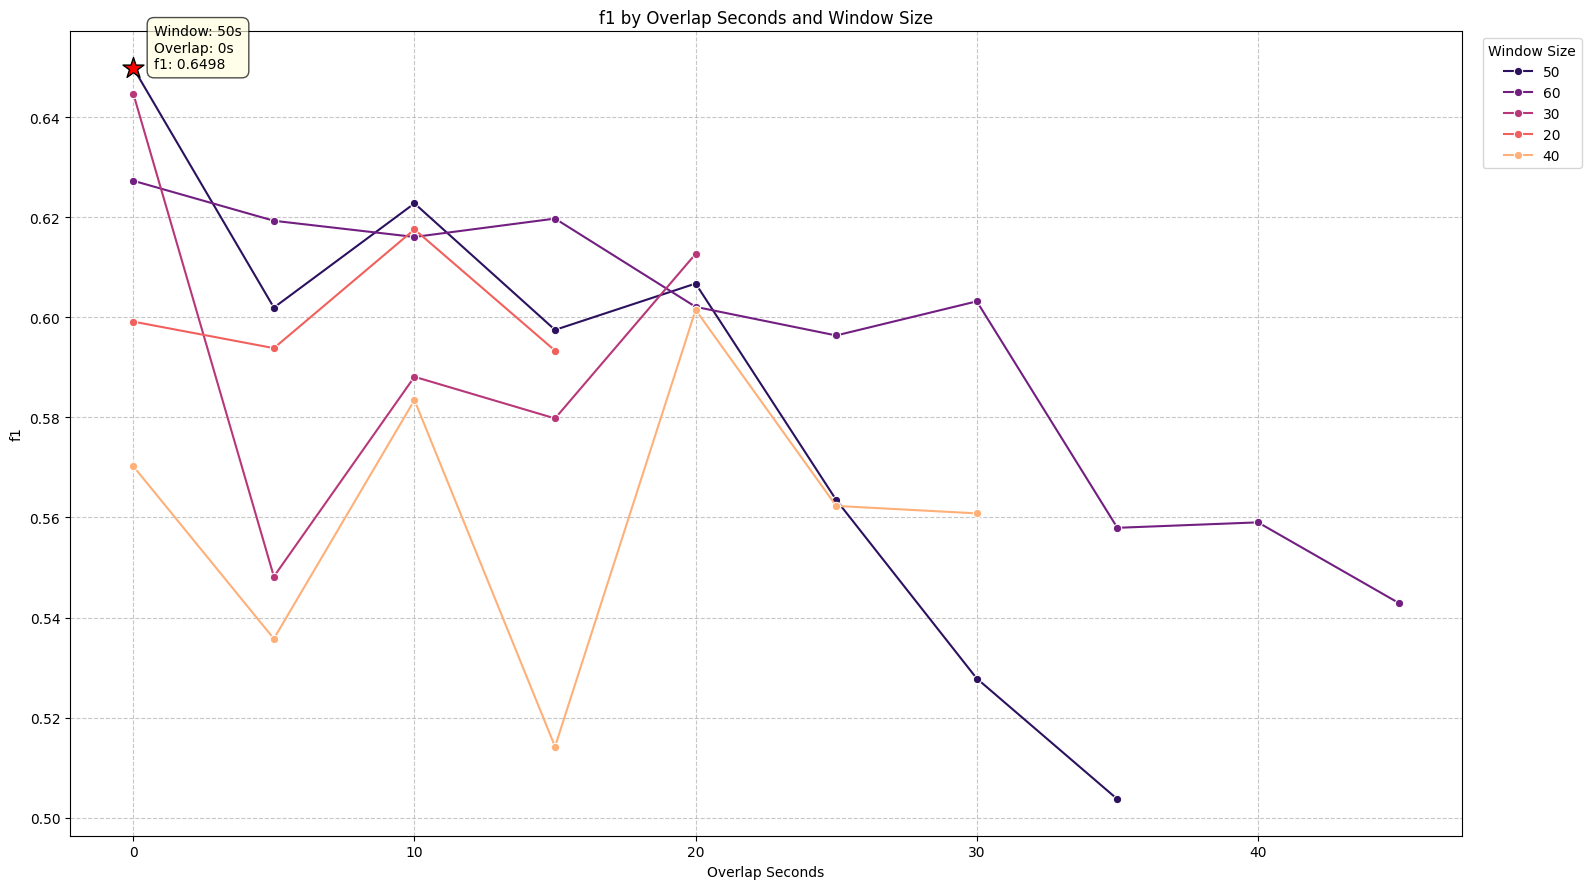

In [12]:
plot_stress_metric(scores_df, 'f1')

Nos quedamos con la siguiente configuración:
- Tamaño de ventana: 50 segundos.
- Solapamiento: 0 segundos.

Hiperparámetros para RF:
- max_depth: 10
- min_samples_split: 5
- n_estimators: 200

Vamos a realizar una selección de características.

In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# --- PARÁMETROS ÓPTIMOS DEL PASO 2 ---
SR = 500
PATH = './data/original'
BEST_WINDOW_SIZE = 50
BEST_OVERLAP = 0

print(f"--- PASO 3: Selección de Características (Ventana: {BEST_WINDOW_SIZE}s) ---")

# 1. Generar el dataset óptimo (usando extracción on-the-fly)
features_df = extract_features_on_the_fly(PATH, sr=SR, window_size=BEST_WINDOW_SIZE, overlap_sec=BEST_OVERLAP)
gt = pd.read_csv('../labels_v2.csv', sep=';')
cv = GroupKFold(n_splits=5) 

# 2. Limpieza, Normalización y Propagación (Merge)
features_df = preprocess_updated(features_df, threshold=30)
features_df = normalize_updated(features_df, by=['Baseline', 'Relax'], clean=True)
test_subjects = get_test_subjects_updated(features_df, test_size=0.20, random_state=RANDOM_STATE)

features_df['subject/task'] = features_df['subject'].astype(str) + '_' + features_df['activity'].astype(str)
df_optimo = features_df.merge(gt[['subject/task', 'binary-stress']], on='subject/task', how='inner')
df_optimo = df_optimo.rename(columns={'binary-stress': 'target'})

# 3. Split Seguro (Crucial: usar la misma lista de sujetos de Test del paso 1 y 2)
X_train, X_test, y_train, y_test, groups_train, tasks_train, tasks_test = split_data_by_subjects_updated(
    df_optimo, 
    test_subjects, # <-- La lista congelada
    exclude_acts=['Baseline', 'Relax']
)

# 4. Eliminación de Características Altamente Correlacionadas (Colinealidad)
print(f"Total de features originales extraídas: {X_train.shape[1]}")
X_train_filtered, X_test_filtered = drop_correlated_features(X_train, X_test, threshold=0.95)
print(f"Features restantes tras filtro de correlación (>0.95): {X_train_filtered.shape[1]}")

# 5. Búsqueda del número óptimo de características mediante RFE
# Evaluaremos cuál es el punto dulce de features
num_features_to_test = [5, 10, 15, 20, 25, 30]
rfe_results = []

# Usamos el modelo con los hiperparámetros de tu búsqueda inicial
base_model = RandomForestClassifier(**best_hyperparams, class_weight='balanced', random_state=RANDOM_STATE)

for n_feat in num_features_to_test:
    # Evitar pedir más features de las que sobrevivieron al filtro de correlación
    if n_feat > X_train_filtered.shape[1]:
        continue
        
    print(f"\nExtrayendo el Top {n_feat} features mediante RFE...")
    
    # Aplicar RFE
    X_train_rfe, X_test_rfe, selected_features = apply_rfe(
        model=base_model, 
        X_train=X_train_filtered, 
        X_test=X_test_filtered, 
        y_train=y_train, 
        num_features=n_feat
    )
    
    # Validar este subconjunto de características mediante Cross Validation
    cv_results = cross_validate(
        base_model,
        X_train_rfe,
        y_train, 
        groups=groups_train, 
        cv=cv, # Tu GroupKFold de 5 splits
        scoring={'balanced_accuracy': 'balanced_accuracy', 'f1': 'f1'}, 
        n_jobs=-1
    )
    
    mean_bacc = np.mean(cv_results['test_balanced_accuracy'])
    mean_f1 = np.mean(cv_results['test_f1'])
    print(f"Rendimiento (CV): Balanced Accuracy = {mean_bacc:.4f} | F1 = {mean_f1:.4f}")
    
    rfe_results.append({
        'num_features': n_feat,
        'cv_balanced_accuracy': mean_bacc,
        'cv_f1': mean_f1,
        'selected_features': selected_features
    })

# --- EVALUACIÓN FINAL DEL PASO 3 ---
rfe_df = pd.DataFrame(rfe_results).sort_values(by='cv_balanced_accuracy', ascending=False).reset_index(drop=True)

print("\n=======================================================")
print("RANKING DE SUBCONJUNTOS DE CARACTERÍSTICAS (RFE)")
print("=======================================================")
print(rfe_df[['num_features', 'cv_balanced_accuracy', 'cv_f1']].to_string(index=False))

best_config = rfe_df.iloc[0]
final_features = best_config['selected_features']

print(f"\nLas características ({best_config['num_features']}) para el Paso 4 son:")
for feat in final_features:
    print(f"- {feat}")

--- PASO 3: Selección de Características (Ventana: 50s) ---
Sujetos seleccionados para Test: ['9j3o', 'dmbd', 'k67g', 'ctzy', 'm8g5', 'g9j5', 'uymz', 'v8mh', 'k2v7', 'a1k9', '8g4y', 'd4n6', 'w2t5']
Total de features originales extraídas: 104
Features restantes tras filtro de correlación (>0.95): 87

Extrayendo el Top 5 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.6592 | F1 = 0.6224

Extrayendo el Top 10 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.6723 | F1 = 0.6395

Extrayendo el Top 15 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.7046 | F1 = 0.6773

Extrayendo el Top 20 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.6745 | F1 = 0.6475

Extrayendo el Top 25 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.6739 | F1 = 0.6474

Extrayendo el Top 30 features mediante RFE...
Rendimiento (CV): Balanced Accuracy = 0.6923 | F1 = 0.6656

RANKING DE SUBCONJUNTOS DE CARACTERÍSTICAS (RFE)
 num_features  

## Subject-independent CV evaluation

In [ ]:
# ============================================================
# Subject-independent outer CV + inner grid search
# Task-level metrics, mean ± std across folds
# ============================================================

from collections import OrderedDict

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
)

from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier


OUTER_SPLITS = 5
INNER_SPLITS = 3
THRESHOLDS = np.arange(0.10, 0.90, 0.02)


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def safe_stratified_group_cv(y, groups, max_splits=5):
    y = pd.Series(y).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)

    n_splits = min(
        max_splits,
        int(y.value_counts().min()),
        int(groups.nunique()),
    )

    if n_splits < 2:
        raise ValueError(
            f"Not enough class examples/groups for grouped CV. "
            f"class_counts={y.value_counts().to_dict()}, "
            f"n_groups={groups.nunique()}"
        )

    return StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )


def tune_threshold_cv(y_true, probs, thresholds=THRESHOLDS):
    y_true = pd.Series(y_true).astype(int).to_numpy()
    probs = np.asarray(probs)

    best_thresh = 0.50
    best_bacc = -np.inf

    for thresh in thresholds:
        preds = (probs >= thresh).astype(int)
        bacc = balanced_accuracy_score(y_true, preds)

        if bacc >= best_bacc:
            best_bacc = bacc
            best_thresh = float(thresh)

    return best_thresh


def compute_physio_metrics(y_true, probs, threshold):
    y_true = pd.Series(y_true).astype(int).to_numpy()
    probs = np.asarray(probs)
    preds = (probs >= threshold).astype(int)

    row = {
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "f1": f1_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall_no_stress": recall_score(y_true, preds, pos_label=0, zero_division=0),
        "recall_stress": recall_score(y_true, preds, pos_label=1, zero_division=0),
    }

    row["roc_auc"] = roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan
    return row


def summarize_physio_cv(fold_df, group_cols):
    metric_cols = [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "precision",
        "recall_no_stress",
        "recall_stress",
        "roc_auc",
    ]

    rows = []

    for keys, group in fold_df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))

        for metric in metric_cols:
            row[f"{metric}_mean"] = group[metric].mean()
            row[f"{metric}_std"] = group[metric].std(ddof=1)

        row["n_folds"] = group["fold"].nunique()
        row["n_tasks_mean"] = group["n_test_tasks"].mean()
        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["balanced_accuracy_mean", "f1_mean", "accuracy_mean"],
            ascending=False,
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# Model grids
# ------------------------------------------------------------

def make_physio_model_grids(y_train):
    """
    Small nested grids for final physiology evaluation.
    These are tuned only inside each outer training fold.
    """

    y_train = pd.Series(y_train).astype(int)

    n_neg = int(y_train.eq(0).sum())
    n_pos = int(y_train.eq(1).sum())
    scale_pos_weight = n_neg / max(n_pos, 1)

    model_grids = OrderedDict()

    # Logistic Regression
    model_grids["logreg"] = (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            )),
        ]),
        {
            "clf__C": [0.01, 0.1, 1.0, 10.0],
        },
    )

    # Random Forest
    model_grids["random_forest"] = (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        {
            "clf__n_estimators": [200, 500],
            "clf__max_depth": [None, 4, 8],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", 0.5],
        },
    )

    # Balanced Random Forest
    model_grids["balanced_rf"] = (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", BalancedRandomForestClassifier(
                sampling_strategy="auto",
                replacement=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        {
            "clf__n_estimators": [200, 500],
            "clf__max_depth": [None, 4, 8],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", 0.5],
        },
    )

    # XGBoost
    model_grids["xgboost"] = (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        {
            "clf__n_estimators": [100, 300],
            "clf__max_depth": [2, 3, 4],
            "clf__learning_rate": [0.03, 0.10],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0],
        },
    )

    # MLP Probe
    model_grids["mlp_probe"] = (
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                max_iter=1000,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        {
            "clf__hidden_layer_sizes": [(16,), (32,), (32, 8)],
            "clf__activation": ["relu", "tanh"],
            "clf__alpha": [0.001, 0.01],
            "clf__learning_rate_init": [0.001, 0.005],
        },
    )

    return model_grids


def fit_tuned_model_with_oof_probs(base_model, param_grid, X_train, y_train, groups_train):
    """
    For one outer fold:
    1. tune hyperparameters with inner subject-independent GridSearchCV
    2. compute OOF probabilities on the outer-training fold using the selected estimator
    3. refit selected estimator on all outer-training data
    """

    inner_cv = safe_stratified_group_cv(
        y_train,
        groups_train,
        max_splits=INNER_SPLITS,
    )

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train, groups=groups_train)

    best_model = grid.best_estimator_

    # OOF probabilities used only to tune the decision threshold.
    train_oof_probs = cross_val_predict(
        clone(best_model),
        X_train,
        y_train,
        groups=groups_train,
        cv=inner_cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    # Refit on the full outer-training fold before predicting outer-test data.
    best_model.fit(X_train, y_train)

    return best_model, train_oof_probs, grid.best_params_, grid.best_score_


# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

def prepare_physio_final_df(df_optimo, final_features):
    df = df_optimo[~df_optimo["activity"].isin(["Baseline", "Relax"])].copy()

    df["target"] = df["target"].astype(int)
    df["subject"] = df["subject"].astype(str)
    df["activity"] = df["activity"].astype(str)

    if "subject/task" not in df.columns:
        df["subject/task"] = df["subject"] + "_" + df["activity"]

    keep = ["subject", "activity", "subject/task", "window_id", "target"] + list(final_features)
    df = df[keep].copy()

    df[final_features] = df[final_features].apply(pd.to_numeric, errors="coerce")

    return df


# ------------------------------------------------------------
# Evaluation 1: aggregate features first, then classify task
# ------------------------------------------------------------

def evaluate_physio_task_feature_cv(
    df_optimo,
    final_features,
    outer_splits=OUTER_SPLITS,
    inner_splits=INNER_SPLITS,
):
    df_base = prepare_physio_final_df(df_optimo, final_features)

    agg_dict = {col: ["mean", "std", "max"] for col in final_features}
    agg_dict["target"] = "first"
    agg_dict["subject"] = "first"

    task_df = df_base.groupby("subject/task").agg(agg_dict).reset_index()

    new_cols = []
    for col in task_df.columns.values:
        if col[0] in ["subject/task", "target", "subject"]:
            new_cols.append(col[0])
        else:
            new_cols.append(f"{col[0]}_{col[1]}")

    task_df.columns = new_cols
    task_df = task_df.fillna(0)

    feature_cols = [c for c in task_df.columns if c not in ["subject/task", "target", "subject"]]

    X = task_df[feature_cols]
    y = task_df["target"].astype(int)
    groups = task_df["subject"].astype(str)

    outer_cv = safe_stratified_group_cv(y, groups, max_splits=outer_splits)

    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), start=1):
        train_subjects = set(groups.iloc[train_idx])
        test_subjects = set(groups.iloc[test_idx])
        assert train_subjects.isdisjoint(test_subjects), "Subject leakage detected."

        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test = X.iloc[test_idx].reset_index(drop=True)

        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_test = y.iloc[test_idx].reset_index(drop=True)

        groups_train = groups.iloc[train_idx].reset_index(drop=True)

        for model_name, (base_model, param_grid) in make_physio_model_grids(y_train).items():
            best_model, train_oof_probs, best_params, best_inner_cv_score = fit_tuned_model_with_oof_probs(
                base_model=base_model,
                param_grid=param_grid,
                X_train=X_train,
                y_train=y_train,
                groups_train=groups_train,
            )

            threshold = tune_threshold_cv(y_train, train_oof_probs)
            test_probs = best_model.predict_proba(X_test)[:, 1]

            fold_rows.append({
                "modality": "physio",
                "evaluation_stage": "task_feature_aggregation",
                "model": model_name,
                "aggregation": "precomputed_task_features",
                "fold": fold,
                "threshold": threshold,
                "best_inner_cv_score": best_inner_cv_score,
                "best_params": str(best_params),
                "n_train_tasks": len(train_idx),
                "n_test_tasks": len(test_idx),
                "n_train_subjects": len(train_subjects),
                "n_test_subjects": len(test_subjects),
                **compute_physio_metrics(y_test, test_probs, threshold),
            })

    fold_df = pd.DataFrame(fold_rows)

    summary = summarize_physio_cv(
        fold_df,
        group_cols=["modality", "evaluation_stage", "model", "aggregation"],
    )

    return summary, fold_df


# ------------------------------------------------------------
# Evaluation 2: classify windows, then aggregate probabilities to task
# ------------------------------------------------------------

def evaluate_physio_window_to_task_cv(
    df_optimo,
    final_features,
    outer_splits=OUTER_SPLITS,
    inner_splits=INNER_SPLITS,
):
    df = prepare_physio_final_df(df_optimo, final_features)

    task_units = (
        df[["subject", "subject/task", "target"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    outer_cv = safe_stratified_group_cv(
        task_units["target"],
        task_units["subject"],
        max_splits=outer_splits,
    )

    aggregation_strategies = OrderedDict({
        "mean": "mean",
        "median": "median",
        "max": "max",
        "p75": lambda x: np.percentile(x, 75),
    })

    fold_rows = []

    for fold, (task_train_idx, task_test_idx) in enumerate(
        outer_cv.split(task_units, task_units["target"], task_units["subject"]),
        start=1,
    ):
        train_subjects = set(task_units.loc[task_train_idx, "subject"].astype(str))
        test_subjects = set(task_units.loc[task_test_idx, "subject"].astype(str))
        assert train_subjects.isdisjoint(test_subjects), "Subject leakage detected."

        train_window_df = (
            df[df["subject"].isin(train_subjects)]
            .dropna(subset=list(final_features) + ["target", "subject", "subject/task"])
            .reset_index(drop=True)
        )

        test_window_df = (
            df[df["subject"].isin(test_subjects)]
            .dropna(subset=list(final_features) + ["target", "subject", "subject/task"])
            .reset_index(drop=True)
        )

        X_train = train_window_df[final_features].to_numpy()
        y_train = train_window_df["target"].astype(int).to_numpy()
        groups_train = train_window_df["subject"].astype(str).to_numpy()

        X_test = test_window_df[final_features].to_numpy()
        y_test = test_window_df["target"].astype(int).to_numpy()

        assert len(X_train) == len(y_train) == len(groups_train), (
            len(X_train),
            len(y_train),
            len(groups_train),
        )

        assert len(X_test) == len(y_test), (
            len(X_test),
            len(y_test),
        )

        for model_name, (base_model, param_grid) in make_physio_model_grids(y_train).items():
            best_model, train_oof_probs, best_params, best_inner_cv_score = fit_tuned_model_with_oof_probs(
                base_model=base_model,
                param_grid=param_grid,
                X_train=X_train,
                y_train=y_train,
                groups_train=groups_train,
            )

            test_probs = best_model.predict_proba(X_test)[:, 1]

            train_base = pd.DataFrame({
                "subject/task": train_window_df["subject/task"].to_numpy(),
                "true_label": y_train,
                "pred_prob": train_oof_probs,
            })

            test_base = pd.DataFrame({
                "subject/task": test_window_df["subject/task"].to_numpy(),
                "true_label": y_test,
                "pred_prob": test_probs,
            })

            for aggregation, agg_func in aggregation_strategies.items():
                train_task = (
                    train_base
                    .groupby("subject/task")
                    .agg(
                        true_label=("true_label", "first"),
                        agg_prob=("pred_prob", agg_func),
                    )
                    .reset_index()
                )

                test_task = (
                    test_base
                    .groupby("subject/task")
                    .agg(
                        true_label=("true_label", "first"),
                        agg_prob=("pred_prob", agg_func),
                    )
                    .reset_index()
                )

                threshold = tune_threshold_cv(
                    train_task["true_label"],
                    train_task["agg_prob"],
                )

                fold_rows.append({
                    "modality": "physio",
                    "evaluation_stage": "window_to_task",
                    "model": model_name,
                    "aggregation": aggregation,
                    "fold": fold,
                    "threshold": threshold,
                    "best_inner_cv_score": best_inner_cv_score,
                    "best_params": str(best_params),
                    "n_train_tasks": train_window_df["subject/task"].nunique(),
                    "n_test_tasks": test_window_df["subject/task"].nunique(),
                    "n_train_subjects": len(train_subjects),
                    "n_test_subjects": len(test_subjects),
                    **compute_physio_metrics(
                        test_task["true_label"],
                        test_task["agg_prob"],
                        threshold,
                    ),
                })

    fold_df = pd.DataFrame(fold_rows)

    summary = summarize_physio_cv(
        fold_df,
        group_cols=["modality", "evaluation_stage", "model", "aggregation"],
    )

    return summary, fold_df


# ------------------------------------------------------------
# Run final evaluation
# ------------------------------------------------------------

physio_task_cv_summary, physio_task_cv_folds = evaluate_physio_task_feature_cv(
    df_optimo,
    final_features,
)

physio_window_cv_summary, physio_window_cv_folds = evaluate_physio_window_to_task_cv(
    df_optimo,
    final_features,
)

physio_cv_summary = pd.concat(
    [physio_task_cv_summary, physio_window_cv_summary],
    ignore_index=True,
)

physio_cv_summary = (
    physio_cv_summary
    .sort_values(
        ["balanced_accuracy_mean", "f1_mean", "accuracy_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)


physio_cv_summary.to_csv("physio_unimodal_subject_cv_summary.csv", index=False)

display(physio_cv_summary.head(30))

,modality,evaluation_stage,model,aggregation,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_no_stress_mean,recall_no_stress_std,recall_stress_mean,recall_stress_std,roc_auc_mean,roc_auc_std,n_folds,n_tasks_mean
0,physio,task_feature_aggregation,mlp_probe,precomputed_task_features,0.671555,0.050787,0.645665,0.053188,0.740141,0.041936,0.685078,0.043842,0.484094,0.091665,0.807236,0.062816,0.691432,0.089579,5,121.2
1,physio,task_feature_aggregation,balanced_rf,precomputed_task_features,0.670852,0.052623,0.640954,0.045651,0.741397,0.054111,0.677528,0.029750,0.460778,0.059429,0.821130,0.092392,0.676238,0.041484,5,121.2
2,physio,window_to_task,xgboost,median,0.646989,0.059803,0.640119,0.061137,0.692293,0.053957,0.701689,0.057975,0.594383,0.091589,0.685855,0.068123,0.689290,0.046338,5,121.2
3,physio,window_to_task,xgboost,mean,0.645258,0.068098,0.635578,0.069797,0.695465,0.060918,0.694765,0.066066,0.570465,0.109671,0.700692,0.082635,0.686128,0.049788,5,121.2
4,physio,task_feature_aggregation,random_forest,precomputed_task_features,0.651691,0.033898,0.630379,0.031858,0.715774,0.041692,0.678568,0.028051,0.499620,0.079293,0.761137,0.080089,0.679476,0.039718,5,121.2
5,physio,task_feature_aggregation,xgboost,precomputed_task_features,0.644864,0.036415,0.628850,0.035362,0.703851,0.039212,0.682020,0.038830,0.526845,0.079811,0.730855,0.072866,0.690476,0.044669,5,121.2
6,physio,window_to_task,random_forest,median,0.636621,0.029823,0.625656,0.026842,0.687255,0.037098,0.685719,0.028576,0.559608,0.065795,0.691705,0.067144,0.681583,0.049404,5,121.2
7,physio,window_to_task,random_forest,mean,0.636686,0.030791,0.624335,0.034008,0.688946,0.033736,0.685792,0.037241,0.552311,0.100482,0.696360,0.066405,0.679616,0.052387,5,121.2
8,physio,window_to_task,balanced_rf,mean,0.628516,0.046987,0.623365,0.043339,0.668841,0.059832,0.691822,0.048788,0.590386,0.110070,0.656344,0.112055,0.676414,0.056297,5,121.2
9,physio,window_to_task,xgboost,p75,0.637552,0.058057,0.623071,0.061213,0.695277,0.050345,0.681005,0.055517,0.531858,0.112546,0.714283,0.074581,0.675481,0.052235,5,121.2
